3. WaveNet'i kur. 8 harfi tek seferde düzleştirmek yerine ikişer ikişer birleştir, üç katmanda tek vektöre in. Her katmanın çıktısının şeklini yazdır ve o şeklin neden öyle olduğunu kendi cümlelerinle yaz. (21:36 - 37:41)

In [ ]:

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:

words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [ ]:

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [ ]:

import random
random.seed(42)
random.shuffle(words)

In [ ]:
block_size = 8 

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] 

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [19]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e


In [ ]:
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

In [ ]:
class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]


In [ ]:
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []


In [ ]:
class Embedding:
  
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))
    
  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
  
  def parameters(self):
    return [self.weight]


In [ ]:
class FlattenConsecutive:
  def __init__(self,n):
    self.n=n
  def __call__(self, x):
    B,T,C = x.shape
    x = x.view(B,T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out

  def parameters(self):
    return []

### WaveNet Açıklama
Flatten classında 8 karakter de aynı anda verilip dumduz 8 karakterli bir context olusuyordu ve modele 8i birden verildiği için aralardaki gizli bağlantıları göremiyordu. waveNet sayesinde 8 karakteri önce ikili şekilde bir layera berdik sonra dörterli şekilde bir layera verdik en son da 8li olarak layera verdik ve aralarındaki gizli bağlantıları gözden kaçırmamış ve hesaplayabilmiş oldu

In [ ]:
# Harfler:     [H1, H2]    [H3, H4]    [H5, H6]    [H7, H8]    (8 harf)
#                 \  /        \  /        \  /        \  /
# 1. Katman:     [Çift 1]    [Çift 2]    [Çift 3]    [Çift 4]     (4 çift)
#                     \          /            \          /
# 2. Katman:           [Dörtlü 1]              [Dörtlü 2]        (2 dörtlü)
#                             \                      /
# 3. Katman:                        [Tek Temsil]             (1 nihai vektör)


In [ ]:
class Sequential:
  
  def __init__(self, layers):
    self.layers = layers
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [ ]:
n_embd = 10
n_hidden = 200 # 10 +10 10*2
# 3 katmanlı wavenet mimarisi
model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),  
  Linear(n_hidden, vocab_size),
])

#logitlere eşit olasılık verebilmesş şçşn değerleri 0'a yaklaştırıyoruz
with torch.no_grad():
  model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

170897


In [ ]:
ix = torch.randint(0, Xtr.shape[0], (4,)) 
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0, 16,  5,  1, 18],
        [ 0,  0,  0,  4,  5, 22,  5,  1],
        [ 0,  0,  0,  0,  1, 26, 26,  1],
        [ 0,  0, 15, 12, 21, 10,  9, 13]])

In [30]:
for layer in model.layers:
  print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 200)
BatchNorm1d : (4, 4, 200)
Tanh : (4, 4, 200)
FlattenConsecutive : (4, 2, 400)
Linear : (4, 2, 200)
BatchNorm1d : (4, 2, 200)
Tanh : (4, 2, 200)
FlattenConsecutive : (4, 400)
Linear : (4, 200)
BatchNorm1d : (4, 200)
Tanh : (4, 200)
Linear : (4, 27)


In [ ]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix]
  
  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb)
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad
    
  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  

      0/ 200000: 3.2801
  10000/ 200000: 2.4405
  20000/ 200000: 2.0924
  30000/ 200000: 1.7807
  40000/ 200000: 2.3140
  50000/ 200000: 2.0886
  60000/ 200000: 2.1432
  70000/ 200000: 1.3730
  80000/ 200000: 2.2208
  90000/ 200000: 2.0469
 100000/ 200000: 1.9473
 110000/ 200000: 2.0920
 120000/ 200000: 2.1888
 130000/ 200000: 1.8170
 140000/ 200000: 1.7055
 150000/ 200000: 2.3765
 160000/ 200000: 1.6420
 170000/ 200000: 2.2759
 180000/ 200000: 2.0288
 190000/ 200000: 1.5869


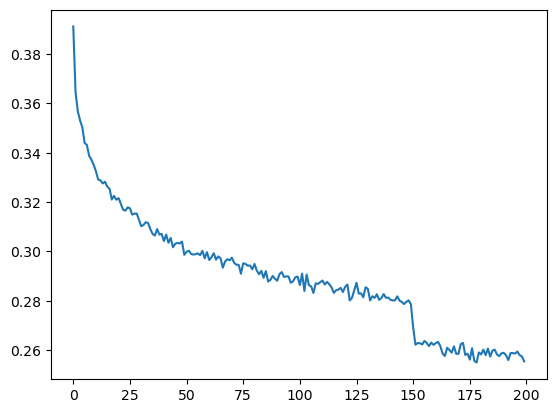

In [32]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [ ]:
for layer in model.layers:
  layer.training = False

In [ ]:
# evaluate the loss
@torch.no_grad()
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.7798768281936646
val 1.981093406677246


In [ ]:
# sample from the model
for _ in range(20):
    
    out = []
    context = [0] * block_size
    while True:
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1).item()
      context = context[1:] + [ix]
      out.append(ix)

      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

thatri.
kadyn.
bexson.
miral.
yohni.
hadi.
ashwa.
amira.
mehan.
wendaline.
calyse.
ahsen.
quathr.
shewa.
sukriya.
khani.
samacha.
anastina.
taluna.
aubrie.
